In [394]:
!pip install mesa --quiet
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_gini(model):
    vessel_wealths = [a.wealth for a in model.agents if isinstance(a, FishingVessel)]
    if not vessel_wealths or sum(vessel_wealths) == 0: return 0
    x = np.sort(vessel_wealths)
    n = len(vessel_wealths)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))

class FishingVessel(mesa.Agent):
    def __init__(self, model, initial_quota, efficiency):
        super().__init__(model)
        self.wealth = 200
        self.efficiency = efficiency
        self.base_quota = initial_quota
        self.quota = self.base_quota # nominal, at beginning
        self.active = True
        self.catch = 0

    def step(self):
        if not self.active: return
        self.catch = 0 # reset annual catch count
        self.wealth -= 100  #the fixed annual cost of staying in the fishing industry, could be part of overall wealth
        # 1. TECHNOLOGY UPGRADE PHASE
        # Wealthy vessels reinvest in better technology
        if self.wealth > 500 and self.efficiency > 3.0:
            upgrade_cost = 300
            self.wealth -= upgrade_cost
            # Lower cost = more efficient, but less progress as you approach minimum 3.0
            self.efficiency -= 0.1*max(0.,self.efficiency-3.0)
            self.model.total_upgrades += 1


        # 2. TRADING & FISHING
        # vessel can only sell quota if prompted by a buyer, or fish if no bid, else quota is not used
        
        if self.model.fish_price >= self.efficiency + self.model.quota_price:
            room = self.model.quota_cap - self.quota #quota cap is not modified by tac restrictions
            if room > 0:
                 # Constants for the trade
                MIN_TRADE = 1.0  # Minimum quota amount worth trading
                MAX_PER_TRADE = 100  # Maximum quota allowed per single trade
                
                # 1. Buyer calculates bid based on OWN margin
                buyer_margin = self.model.fish_price - self.efficiency
                bid_price = 0.7 * buyer_margin
                
                # Only proceed if fishing is actually profitable (bid is positive)
                if bid_price > 0:
                    
                    for _ in range(2):  # several attempt but not perfect market
                        if room < MIN_TRADE:
                            break
                
                        # 2. Filter for valid sellers: 
                        # Must have enough quota to meet the MIN_TRADE threshold
                        potential_sellers = [
                            a for a in self.model.agents
                            if type(a) == type(self)  # Ensure agent is a Fisher, not a Regulator
                            if a != self 
                            and getattr(a, "active", True) 
                            and a.quota >= MIN_TRADE
                        ]
                
                        if not potential_sellers:
                            break
                
                        # 3. Pick a random seller and evaluate their willingness
                        seller = self.random.choice(potential_sellers)
                        seller_margin = self.model.fish_price - seller.efficiency
                
                        # Seller accepts if bid is better than their own fishing margin
                        if bid_price > seller_margin:
                            # Determine amount: at least MIN_TRADE, up to seller's stock, buyer's room, or 100
                            to_buy = min(seller.quota, room, MAX_PER_TRADE)
                            total_cost = to_buy * bid_price
                
                            if self.wealth >= total_cost:
                                # Execute Trade
                                self.wealth -= total_cost
                                self.quota += to_buy
                                seller.wealth += total_cost
                                seller.quota -= to_buy
                                
                                # Update model metrics
                                self.model.vessels_quota_sold += 1
                            else:
                                # Can't afford this specific batch, try another seller
                                continue
                        else:
                            # Seller profit > Bid, try another seller
                            continue
            # Buying cycle ends
            
            # Now consider fishing
        if self.quota > 0 and self.model.fish_price > self.efficiency: #you only fish if wealth gain otherwise drop
            self.wealth += self.quota * (self.model.fish_price - self.efficiency)
            self.model.total_catch += self.quota
            self.catch += self.quota
            self.quota = 0

        # 3. BANKRUPTCY CHECK (Moved after regulator subsidies in model.step)
        if self.wealth <= 0:
            self.active = False
            self.model.vessels_bankrupt += 1
            self.model.agents.remove(self)

class Regulator(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth, self.efficiency, self.quota, self.catch = None, None , None, None
        self.fishery_fund = 0  # <--- Ensure this is here
        
    def step(self):
        # A. FISCAL POLICY: TAX & SUBSIDIZE
        for a in self.model.agents:
            if isinstance(a, FishingVessel):
                # Progressive Tax: 10% on wealth over 800
                if a.wealth > 800:
                    tax = (a.wealth - 800) * 0.10
                    a.wealth -= tax
                    self.fishery_fund += tax
                
                # Subsidy: If wealth < 40, give 50 units from fund
                if a.wealth >=0 and a.wealth < 40 and self.fishery_fund >= 50:
                    a.wealth += 40
                    self.fishery_fund -= 40
                    self.model.total_subsidies_given += 1

        # B. ENVIRONMENT & PRICES
        if self.random.random() < 0.25:   
            self.model.tac_multiplier = 0.4 # tac totally restricted regardless of quota, equal distribution
            self.model.shock_active = 1
        else:
            # move over unused quota from previous period
            #if self.model.shock_active == 0:
            #    self.model.tac_multiplier = 1.0 + (1.-self.model.total_catch/self.model.quota_total) #added from previous year
            # adjust because of bankrupt vessels that do not get quota anymore
            self.model.tac_multiplier = 1.
            #self.model.tac_multiplier = self.model.tac_multiplier/(1.-self.model.vessels_bankrupt/self.model.n_vessels)
            self.model.shock_active = 0

        # Dynamic Pricing of fish
        self.model.fish_price = self.random.gauss(self.model.nominal_fish_price, 1.5)

        # Just filter by type; since bankrupt ones were removed, 
        # any FishingVessel found is currently active.
        active_vessels = [a for a in self.model.agents if isinstance(a, FishingVessel)]
        n_active_vessels = len(active_vessels)
        
        if n_active_vessels > 0:
            # Now assign your quota based on this count
            quota_per_vessel = self.model.quota_total / n_active_vessels * self.model.tac_multiplier
            for v in active_vessels:
                v.quota = quota_per_vessel
  
        # Reset counters
        self.model.total_catch = 0
        self.model.total_demand = 0
        self.model.total_supply = 0
        #self.model.vessels_quota_sold = 0
        #self.model.total_upgrades =0


class FisheryModel(mesa.Model):
    def __init__(self, n_vessels, efficiencies_list, quota_cap=200):
        super().__init__()
        self.running = True
        self.nominal_fish_price = 15
        self.fish_price = self.nominal_fish_price
        self.quota_price = 2.0
        self.tac_multiplier = 1.0
        self.shock_active = 0
        self.quota_cap = quota_cap # restriction per vessel
        self.quota_total = 2000 #annual total quota
        self.n_vessels=n_vessels
        # --- ADD THESE MISSING ATTRIBUTES ---
        self.total_upgrades = 0       # Fixes your AttributeError
        self.vessels_bankrupt = 0
        self.vessels_quota_sold = 0
        self.total_subsidies_given = 0
        self.total_demand = 0
        self.total_catch = 0
        self.total_supply = 0
        # ------------------------------------
        self.regulator = Regulator(self)
        model_reporters=[]
        agent_reporters=[]
        iquota = self.quota_total / n_vessels
        # Instead of generating new randoms, use the provided list
        for eff in efficiencies_list:
            # Mesa 3.0 automatically handles IDs (1, 2, 3...) in the order created
            FishingVessel(self, initial_quota=iquota, efficiency=eff)

        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Gini": compute_gini, 
             "Active_Vessels": lambda m: len([
                    a for a in m.agents if isinstance(a, FishingVessel) and a.active == True]),
                "Fund_Balance": lambda m: m.regulator.fishery_fund, # <--- Matches regulator attribute
                "Subsidies": "total_subsidies_given",
                "Quota_sold": "vessels_quota_sold",
                "Tech_upgrade": "total_upgrades",
                "Catch": "total_catch",
                "Fish_price": "fish_price"
            },
            agent_reporters={"Wealth": "wealth", "Efficiency": "efficiency", "Quota": "quota", "Catch": "catch"}
        )
    def step(self):
        # 1. Shuffle and step only the Fisher agents
        # This ensures all private trading happens first in random order
        fishers = self.agents.select(lambda a: isinstance(a, FishingVessel))
        fishers.shuffle_do("step")
        # 2. Collect data after everyone has finished
        self.datacollector.collect(self)    
        # 3. Step the Regulator last
        # This ensures it only assigns quota or collects taxes after all trades
        regulators = self.agents.select(lambda a: isinstance(a, Regulator))
        regulators.do("step")

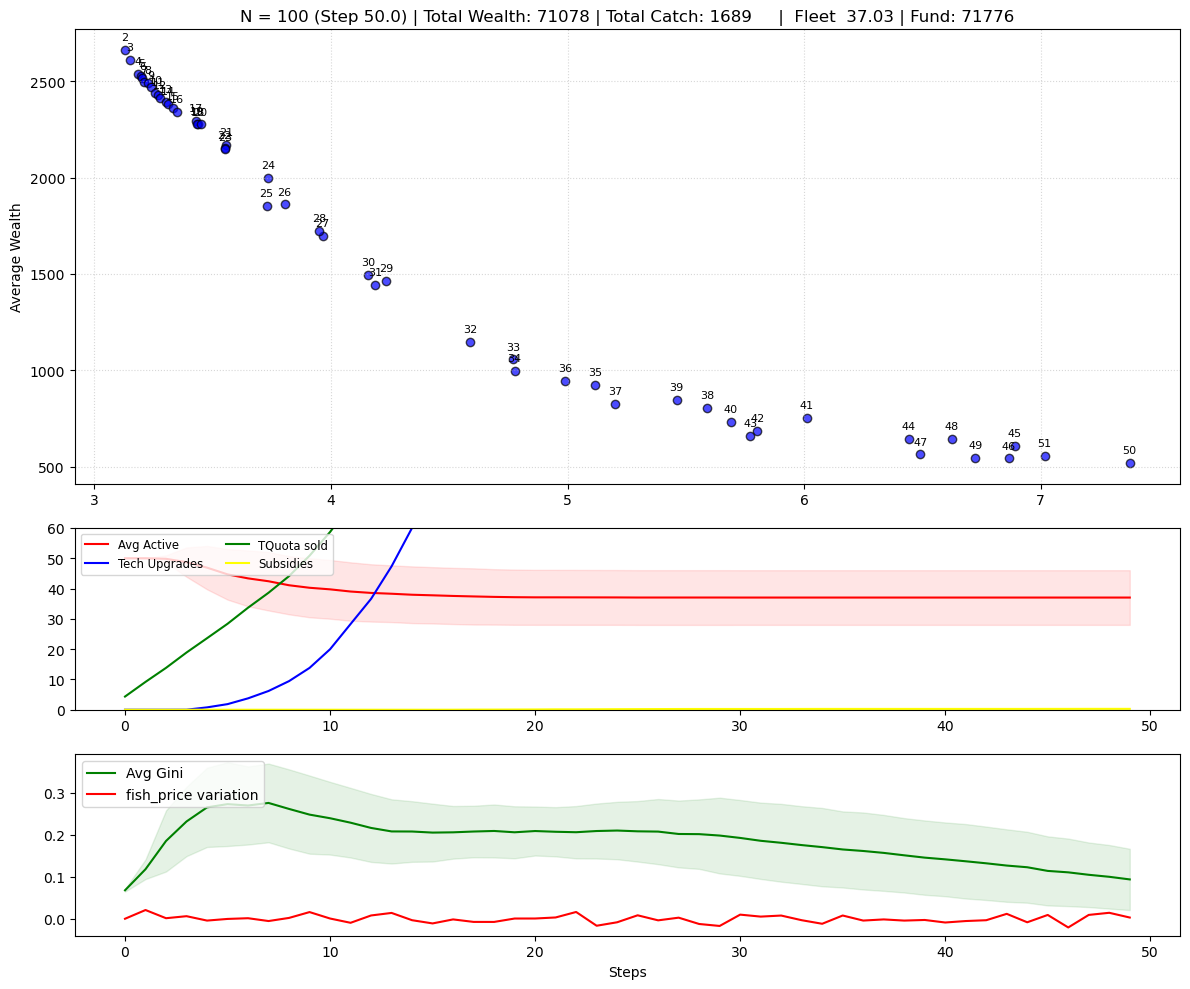

In [396]:
# --- RUN CONFIGURATION ---
NUM_RUNS = 100 # Higher number gives better averages
STEPS = 50 # how many periods to consider
n_vessels = 50 # how many vessels begin reiceiving quota
# now vessels are assigned efficiencies (cost of catching one unit), and sorted, no. 1 most efficeint
# with nominal fish price at 15, one can change the range for efficiencies
fixed_efficiencies = sorted([np.random.uniform(11, 13) for _ in range(n_vessels)])

all_final_states = []
model_stats_list = []

for r in range(NUM_RUNS):
    model = FisheryModel(n_vessels=n_vessels, efficiencies_list=fixed_efficiencies)
    for _ in range(STEPS):
        model.step()
    
    # 1. Store Model Data for the line charts
    m_df = model.datacollector.get_model_vars_dataframe()
    m_df['Run'] = r
    model_stats_list.append(m_df)
    
    # 2. Store only the LAST step of this run for the scatter plot
    agent_df = model.datacollector.get_agent_vars_dataframe()
    last_step = agent_df.index.get_level_values('Step').max()
    all_final_states.append(agent_df.xs(last_step, level="Step"))

# --- AGGREGATE AFTER ALL RUNS ---
# This combines all runs and calculates the mean for each AgentID
vessel_averages = pd.concat(all_final_states).groupby(level="AgentID").mean()
combined_model = pd.concat(model_stats_list)
stats = combined_model.groupby(level=0).agg(['mean', 'std'])
total_wealth = np.mean([agent_df["Wealth"].sum() for agent_df in all_final_states])
total_catch = np.mean(stats[('Catch', 'mean')])
Fleet = stats[('Active_Vessels', 'mean')].iloc[-1]
Fund_balance= stats[('Fund_Balance','mean')].iloc[-1]
# --- VISUALIZATION ---
fig, (ax_main, ax_fleet, ax_gini) = plt.subplots(3, 1, figsize=(12, 10), 
                                                 gridspec_kw={'height_ratios': [2.5, 1, 1]})

# TOP PLOT: Use vessel_averages (Only n_vessels dots)
ax_main.scatter(vessel_averages["Efficiency"], vessel_averages["Wealth"], 
                color='blue', alpha=0.7, edgecolors='black')

for agent_id, row in vessel_averages.iterrows():
    ax_main.annotate(f"{agent_id}", (row["Efficiency"], row["Wealth"]),
                     textcoords="offset points", xytext=(0,7), ha='center', fontsize=8)
ax_main.set_title(
    f"N = {NUM_RUNS} (Step {last_step}) | Total Wealth: {total_wealth:.0f} | Total Catch: {total_catch:.0f} \
    |  Fleet  {Fleet} | Fund: {Fund_balance:.0f}" )
#ax_main.set_title(f"Mean Vessel Performance after {NUM_RUNS} Runs")
ax_main.set_ylabel("Average Wealth")
ax_main.grid(True, linestyle=':', alpha=0.5)

# --- MIDDLE & BOTTOM: TRENDS (Averages) ---
steps = stats.index
# Active Vessels Trend
ax_fleet.plot(steps, stats[('Active_Vessels', 'mean')], color="red", label="Avg Active")
ax_fleet.fill_between(steps, stats[('Active_Vessels', 'mean')] - stats[('Active_Vessels', 'std')],
                      stats[('Active_Vessels', 'mean')] + stats[('Active_Vessels', 'std')], color='red', alpha=0.1)
ax_fleet.plot(steps, stats[("Tech_upgrade", 'mean')], color="blue", label="Tech Upgrades")
ax_fleet.plot(steps, stats[("Quota_sold", 'mean')], color="green", label="TQuota sold")
ax_fleet.plot(steps, stats[("Subsidies", 'mean')], color="yellow", label="Subsidies")
ax_fleet.set_ylim(0, 60)
ax_fleet.legend(loc="upper right")
ax_fleet.legend(loc="upper left", fontsize='small', ncol=2)

# Gini Trend
ax_gini.plot(steps, stats[('Gini', 'mean')], color="green", label="Avg Gini")
ax_gini.fill_between(steps, stats[('Gini', 'mean')] - stats[('Gini', 'std')],
                     stats[('Gini', 'mean')] + stats[('Gini', 'std')], color='green', alpha=0.1)
ax_gini.plot(steps, stats[("Fish_price",'mean')]/15-1, color="red", label="fish_price variation")
ax_gini.set_xlabel("Steps")
ax_gini.legend(loc="upper left")

plt.tight_layout()
plt.show()
